In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [41]:
# Executar 01-PreProcessamento.py antes de fazer a analise
df_analise = pd.read_csv("../dados/TS_FINAL.csv", encoding='latin-1')

In [42]:
print("=" * 80)
print("VERIFICAÇÃO DAS VARIÁVEIS ALVO (NIVEL_LP e NIVEL_MT)")
print("=" * 80)

print(f"   NIVEL_LP: {df_analise['NIVEL_LP'].nunique()} níveis únicos")
print(f"   NIVEL_MT: {df_analise['NIVEL_MT'].nunique()} níveis únicos")


VERIFICAÇÃO DAS VARIÁVEIS ALVO (NIVEL_LP e NIVEL_MT)
   NIVEL_LP: 9 níveis únicos
   NIVEL_MT: 11 níveis únicos


# Análise Exploratória dos Dados Pré-Processados

## Objetivo
Esta análise visa compreender a estrutura, distribuição e características dos dados pré-processados para o projeto de previsão de proficiência em Língua Portuguesa e Matemática. Vamos examinar:

- **Estrutura geral**: dimensões, tipos de dados, valores ausentes
- **Variáveis alvo**: distribuição dos níveis de proficiência
- **Features numéricas**: estatísticas e distribuições
- **Features categóricas**: frequências e proporções
- **Correlações**: relações entre variáveis e as variáveis alvo


In [43]:
# 1. VISÃO GERAL DOS DADOS

print("=" * 80)
print("VISÃO GERAL DOS DADOS PRÉ-PROCESSADOS")
print("=" * 80)

print("\n◉ Dimensões do Dataset:")
print(f"   Linhas (amostras): {df_analise.shape[0]:,}")
print(f"   Colunas (features): {df_analise.shape[1]}")

print("-" * 60)

print("\n◉ Tipos de Dados:")
print(df_analise.dtypes.value_counts())

print("-" * 60)

print("\n◉ Valores Ausentes (Missing Values):")
missing = df_analise.isnull().sum()
missing_pct = (missing / len(df_analise)) * 100
missing_df = pd.DataFrame({
    'Ausentes': missing,
    'Percentual (%)': missing_pct
}).sort_values('Ausentes', ascending=False)
missing_df = missing_df[missing_df['Ausentes'] > 0]

if len(missing_df) > 0:
    print(missing_df.to_string())
else:
    print("  ✓ Nenhum valor ausente detectado!")



VISÃO GERAL DOS DADOS PRÉ-PROCESSADOS

◉ Dimensões do Dataset:
   Linhas (amostras): 1,514,448
   Colunas (features): 80
------------------------------------------------------------

◉ Tipos de Dados:
str        39
float64    32
int64       9
Name: count, dtype: int64
------------------------------------------------------------

◉ Valores Ausentes (Missing Values):
                           Ausentes  Percentual (%)
MEDIA_EM_MT                  331568       21.893654
MEDIA_EM_LP                  331568       21.893654
TX_Q022                      290322       19.170153
TX_Q087                      289785       19.134695
TX_Q035                      288749       19.066287
TX_Q020                      288545       19.052817
TX_Q082                      288220       19.031357
TX_Q208                      287874       19.008510
TX_Q079                      286518       18.918972
TX_Q083                      286468       18.915671
TX_Q085                      286370       18.909200
TX_Q078 

## 2. Análise das Variáveis Alvo

As variáveis alvo representam os níveis de proficiência dos alunos de acordo com a escala SAEB:
- **NIVEL_LP**: Nível de Proficiência em Língua Portuguesa (0-8)
- **NIVEL_MT**: Nível de Proficiência em Matemática (0-10)


In [44]:
print("\n" + "=" * 80)
print("ANÁLISE DAS VARIÁVEIS ALVO")
print("=" * 80)

# Verificar se as colunas de nível existem
if 'NIVEL_LP' in df_analise.columns:
    print("\n◉ Distribuição - NIVEL_LP (Língua Portuguesa):")
    nivel_lp_counts = df_analise['NIVEL_LP'].value_counts().sort_index()
    nivel_lp_pct = (nivel_lp_counts / len(df_analise) * 100).round(2)
    
    for nivel, count in nivel_lp_counts.items():
        pct = nivel_lp_pct[nivel]
        bar = "█" * int(pct / 2)
        print(f"   Nível {int(nivel):2d}: {count:>10,} ({pct:>6.2f}%) {bar}")
    
    print(f"\n   Estatísticas: Mín={nivel_lp_counts.index.min()}, Máx={nivel_lp_counts.index.max()}, Moda={df_analise['NIVEL_LP'].mode().values[0]}")

if 'NIVEL_MT' in df_analise.columns:
    print("\n◉ Distribuição - NIVEL_MT (Matemática):")
    nivel_mt_counts = df_analise['NIVEL_MT'].value_counts().sort_index()
    nivel_mt_pct = (nivel_mt_counts / len(df_analise) * 100).round(2)
    
    for nivel, count in nivel_mt_counts.items():
        pct = nivel_mt_pct[nivel]
        bar = "█" * int(pct / 2)
        print(f"   Nível {int(nivel):2d}: {count:>10,} ({pct:>6.2f}%) {bar}")
    
    print(f"\n   Estatísticas: Mín={nivel_mt_counts.index.min()}, Máx={nivel_mt_counts.index.max()}, Moda={df_analise['NIVEL_MT'].mode().values[0]}")

# Analisar o balanceamento das classes
if 'NIVEL_LP' in df_analise.columns and 'NIVEL_MT' in df_analise.columns:
    print("\n◉  Balanceamento das Classes:")
    lp_entropy = -((nivel_lp_pct / 100) * np.log2(nivel_lp_pct / 100 + 1e-10)).sum()
    mt_entropy = -((nivel_mt_pct / 100) * np.log2(nivel_mt_pct / 100 + 1e-10)).sum()
    print(f"   Entropia NIVEL_LP (0=uniforme, máx≈{np.log2(len(nivel_lp_counts)):.2f}): {lp_entropy:.3f}")
    print(f"   Entropia NIVEL_MT (0=uniforme, máx≈{np.log2(len(nivel_mt_counts)):.2f}): {mt_entropy:.3f}")



ANÁLISE DAS VARIÁVEIS ALVO

◉ Distribuição - NIVEL_LP (Língua Portuguesa):
   Nível  0:    293,071 ( 19.35%) █████████
   Nível  1:    196,467 ( 12.97%) ██████
   Nível  2:    246,367 ( 16.27%) ████████
   Nível  3:    275,540 ( 18.19%) █████████
   Nível  4:    249,186 ( 16.45%) ████████
   Nível  5:    165,153 ( 10.91%) █████
   Nível  6:     70,509 (  4.66%) ██
   Nível  7:     16,955 (  1.12%) 
   Nível  8:      1,200 (  0.08%) 

   Estatísticas: Mín=0, Máx=8, Moda=0

◉ Distribuição - NIVEL_MT (Matemática):
   Nível  0:    291,588 ( 19.25%) █████████
   Nível  1:    282,570 ( 18.66%) █████████
   Nível  2:    306,529 ( 20.24%) ██████████
   Nível  3:    272,212 ( 17.97%) ████████
   Nível  4:    178,065 ( 11.76%) █████
   Nível  5:    100,407 (  6.63%) ███
   Nível  6:     49,643 (  3.28%) █
   Nível  7:     21,153 (  1.40%) 
   Nível  8:      9,194 (  0.61%) 
   Nível  9:      3,008 (  0.20%) 
   Nível 10:         79 (  0.01%) 

   Estatísticas: Mín=0, Máx=10, Moda=2

◉  Balancea

## 3. Análise Estatística das Features

### Features Numéricas
Vamos analisar as distribuições e estatísticas das variáveis contínuas e discretas.


In [45]:
print("\n" + "=" * 80)
print("ANÁLISE ESTATÍSTICA DAS FEATURES")
print("=" * 80)

# Identificar colunas numéricas e categóricas
numeric_cols = df_analise.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_analise.select_dtypes(include=['object', 'string']).columns.tolist()

# Remover colunas de ID e as variáveis alvo da análise
cols_para_ignorar = ['ID_ALUNO', 'ID_ESCOLA', 'ID_UF', 'ID_AREA', 'ID_SERIE', 'NIVEL_LP', 'NIVEL_MT']
numeric_cols = [col for col in numeric_cols if col not in cols_para_ignorar]

print(f"\n◉ Features Numéricas: {len(numeric_cols)}")
if numeric_cols:
    print(f"   {numeric_cols[:10]}{'...' if len(numeric_cols) > 10 else ''}")
    
    # Estatísticas das features numéricas
    stats = df_analise[numeric_cols].describe().T
    stats['missing_%'] = (df_analise[numeric_cols].isnull().sum() / len(df_analise) * 100).values
    
    print("\n   Resumo Estatístico:")
    print(f"   {'Feature':<30} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'Missing':>8}")
    print("   " + "-" * 80)
    for col in numeric_cols[:15]:  # Mostrar apenas as primeiras 15
        mean_val = df_analise[col].mean()
        std_val = df_analise[col].std()
        min_val = df_analise[col].min()
        max_val = df_analise[col].max()
        missing_pct = (df_analise[col].isnull().sum() / len(df_analise) * 100)
        print(f"   {col:<30} {mean_val:>10.2f} {std_val:>10.2f} {min_val:>10.2f} {max_val:>10.2f} {missing_pct:>7.2f}%")

print(f"\n◉ Features Categóricas: {len(categorical_cols)}")
if categorical_cols:
    print(f"   {categorical_cols}")
    
    print("\n   Contagens de Valores Únicos:")
    for col in categorical_cols[:5]:  # Mostrar apenas as primeiras 5
        unique_count = df_analise[col].nunique()
        missing_count = df_analise[col].isnull().sum()
        print(f"   {col:<30}: {unique_count:>5} valores únicos, {missing_count:>6} ausentes")


ANÁLISE ESTATÍSTICA DAS FEATURES

◉ Features Numéricas: 34
   ['IN_PUBLICA', 'TX_Q020', 'TX_Q022', 'TX_Q032', 'TX_Q033', 'TX_Q035', 'TX_Q036', 'TX_Q056', 'TX_Q057', 'TX_Q078']...

   Resumo Estatístico:
   Feature                              Mean        Std        Min        Max  Missing
   --------------------------------------------------------------------------------
   IN_PUBLICA                           0.98       0.14       0.00       1.00    0.00%
   TX_Q020                             14.84      12.09       0.00      60.00   19.05%
   TX_Q022                             15.74      12.73       0.00      60.00   19.17%
   TX_Q032                              0.74       0.26       0.00       1.00   18.81%
   TX_Q033                              0.77       0.20       0.00       1.00   18.83%
   TX_Q035                              0.50       0.34       0.00       1.00   19.07%
   TX_Q036                              0.63       0.23       0.00       1.00   18.83%
   TX_Q056      

## 4. Visualizações das Variáveis Alvo


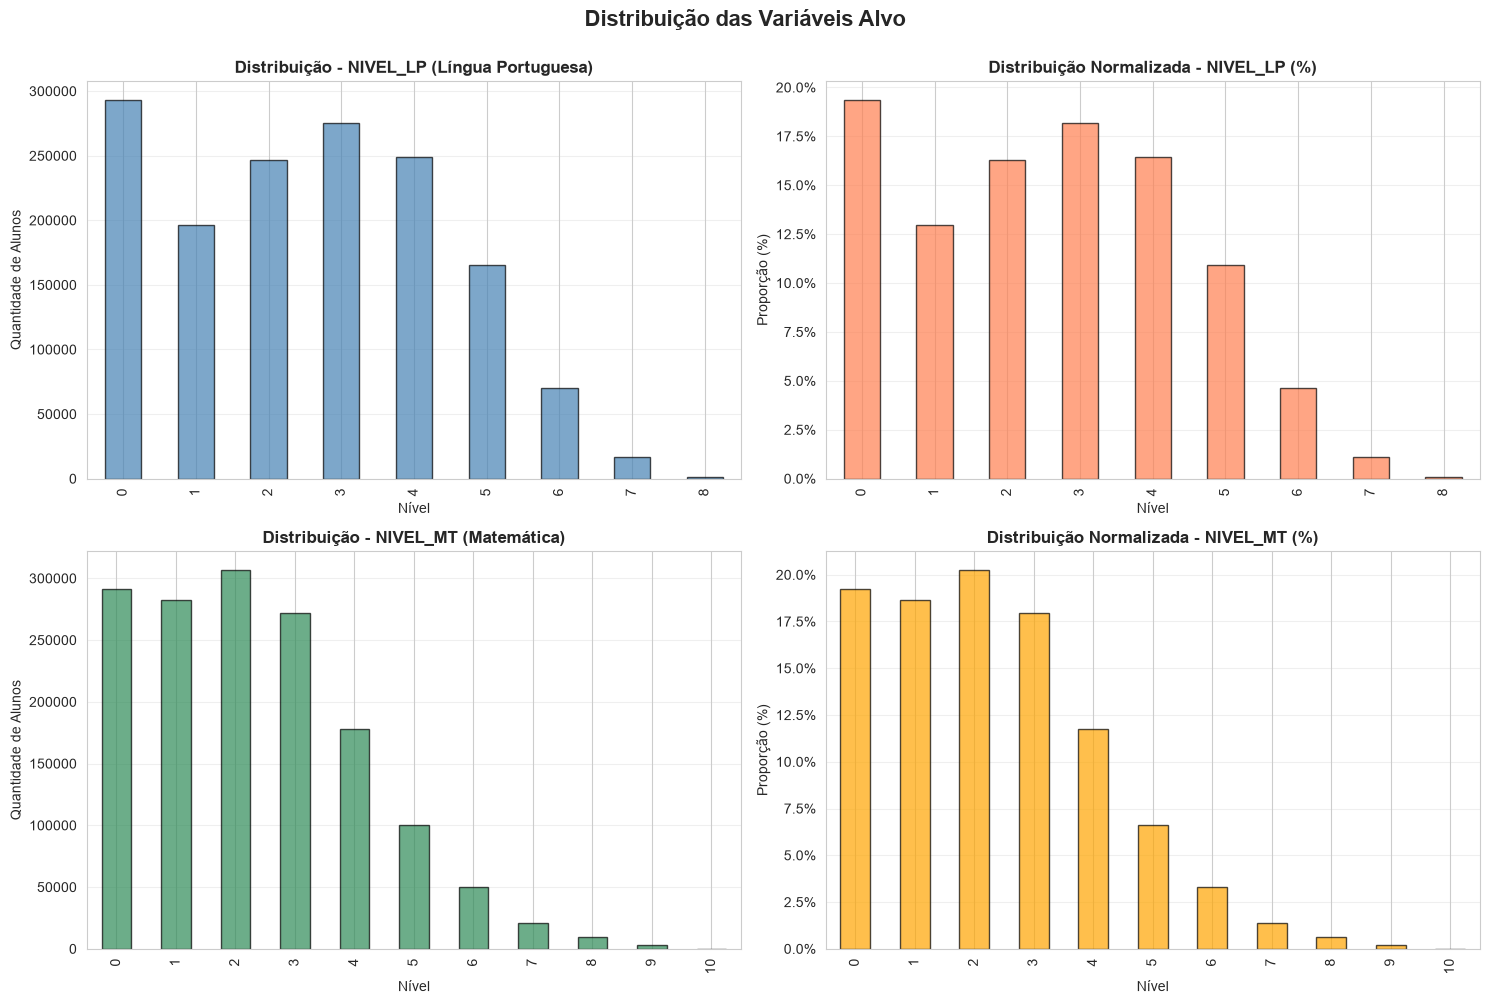

In [46]:
# Configurar estilo do seaborn
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Criar subplots para as distribuições das variáveis alvo
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribuição das Variáveis Alvo', fontsize=16, fontweight='bold', y=1.00)

if 'NIVEL_LP' in df_analise.columns:
    # Histograma - NIVEL_LP
    ax1 = axes[0, 0]
    df_analise['NIVEL_LP'].value_counts().sort_index().plot(
        kind='bar', ax=ax1, color='steelblue', edgecolor='black', alpha=0.7
    )
    ax1.set_title('Distribuição - NIVEL_LP (Língua Portuguesa)', fontweight='bold', fontsize=12)
    ax1.set_xlabel('Nível')
    ax1.set_ylabel('Quantidade de Alunos')
    ax1.grid(axis='y', alpha=0.3)
    
    # Histograma normalizado - NIVEL_LP
    ax2 = axes[0, 1]
    df_analise['NIVEL_LP'].value_counts(normalize=True).sort_index().plot(
        kind='bar', ax=ax2, color='coral', edgecolor='black', alpha=0.7
    )
    ax2.set_title('Distribuição Normalizada - NIVEL_LP (%)', fontweight='bold', fontsize=12)
    ax2.set_xlabel('Nível')
    ax2.set_ylabel('Proporção (%)')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    ax2.grid(axis='y', alpha=0.3)

if 'NIVEL_MT' in df_analise.columns:
    # Histograma - NIVEL_MT
    ax3 = axes[1, 0]
    df_analise['NIVEL_MT'].value_counts().sort_index().plot(
        kind='bar', ax=ax3, color='seagreen', edgecolor='black', alpha=0.7
    )
    ax3.set_title('Distribuição - NIVEL_MT (Matemática)', fontweight='bold', fontsize=12)
    ax3.set_xlabel('Nível')
    ax3.set_ylabel('Quantidade de Alunos')
    ax3.grid(axis='y', alpha=0.3)
    
    # Histograma normalizado - NIVEL_MT
    ax4 = axes[1, 1]
    df_analise['NIVEL_MT'].value_counts(normalize=True).sort_index().plot(
        kind='bar', ax=ax4, color='orange', edgecolor='black', alpha=0.7
    )
    ax4.set_title('Distribuição Normalizada - NIVEL_MT (%)', fontweight='bold', fontsize=12)
    ax4.set_xlabel('Nível')
    ax4.set_ylabel('Proporção (%)')
    ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Análise de Correlações

Vamos examinar as correlações entre as features numéricas e as variáveis alvo.


In [47]:
print("\n" + "=" * 80)
print("ANÁLISE DE CORRELAÇÕES")
print("=" * 80)

# Calcular correlações para variáveis numéricas
numeric_cols_all = df_analise.select_dtypes(include=[np.number]).columns.tolist()

# Calcular matriz de correlação
corr_matrix = df_analise[numeric_cols_all].corr()

# Correlações com NIVEL_LP
if 'NIVEL_LP' in corr_matrix.columns:
    print("\n◉ Top 10 Features com maior Correlação com NIVEL_LP:")
    corr_lp = corr_matrix['NIVEL_LP'].drop('NIVEL_LP').sort_values(ascending=False)
    corr_lp = corr_lp[corr_lp.index != 'NIVEL_MT']  # Remover correlação com MT
    corr_lp = corr_lp[~corr_lp.index.str.contains('ID_')]  # Remover IDs
    
    print(f"   {'Feature':<30} {'Correlação':>12}")
    print("   " + "-" * 45)
    for i, (feat, val) in enumerate(corr_lp.head(10).items(), 1):
        print(f"   {i:2d}. {feat:<27} {val:>12.4f}")

# Correlações com NIVEL_MT
if 'NIVEL_MT' in corr_matrix.columns:
    print("\n◉ Top 10 Features com maior Correlação com NIVEL_MT:")
    corr_mt = corr_matrix['NIVEL_MT'].drop('NIVEL_MT').sort_values(ascending=False)
    corr_mt = corr_mt[corr_mt.index != 'NIVEL_LP']  # Remover correlação com LP
    corr_mt = corr_mt[~corr_mt.index.str.contains('ID_')]  # Remover IDs
    
    print(f"   {'Feature':<30} {'Correlação':>12}")
    print("   " + "-" * 45)
    for i, (feat, val) in enumerate(corr_mt.head(10).items(), 1):
        print(f"   {i:2d}. {feat:<27} {val:>12.4f}")

# Correlação entre as variáveis alvo
if 'NIVEL_LP' in corr_matrix.columns and 'NIVEL_MT' in corr_matrix.columns:
    corr_lp_mt = corr_matrix.loc['NIVEL_LP', 'NIVEL_MT']
    print(f"\n◉ Correlação entre NIVEL_LP e NIVEL_MT: {corr_lp_mt:.4f}")
    if corr_lp_mt > 0.7:
        print("   -  Correlação forte: os níveis de proficiência em LP e MT estão altamente relacionados")
    elif corr_lp_mt > 0.3:
        print("   -  Correlação moderada: existe relação entre LP e MT")
    else:
        print("   -  Correlação fraca: LP e MT são relativamente independentes")



ANÁLISE DE CORRELAÇÕES

◉ Top 10 Features com maior Correlação com NIVEL_LP:
   Feature                          Correlação
   ---------------------------------------------
    1. MEDIA_EM_LP                       0.4014
    2. MEDIA_EM_MT                       0.3652
    3. TX_Q035                           0.1019
    4. PC_FORMACAO_DOCENTE_MEDIO         0.0920
    5. TX_Q108                           0.0848
    6. TX_Q119                           0.0661
    7. TX_Q036                           0.0653
    8. TX_Q194                           0.0649
    9. TX_Q032                           0.0537
   10. TX_Q033                           0.0489

◉ Top 10 Features com maior Correlação com NIVEL_MT:
   Feature                          Correlação
   ---------------------------------------------
    1. MEDIA_EM_MT                       0.4192
    2. MEDIA_EM_LP                       0.3769
    3. TX_Q035                           0.0978
    4. TX_Q108                           0.0857
    

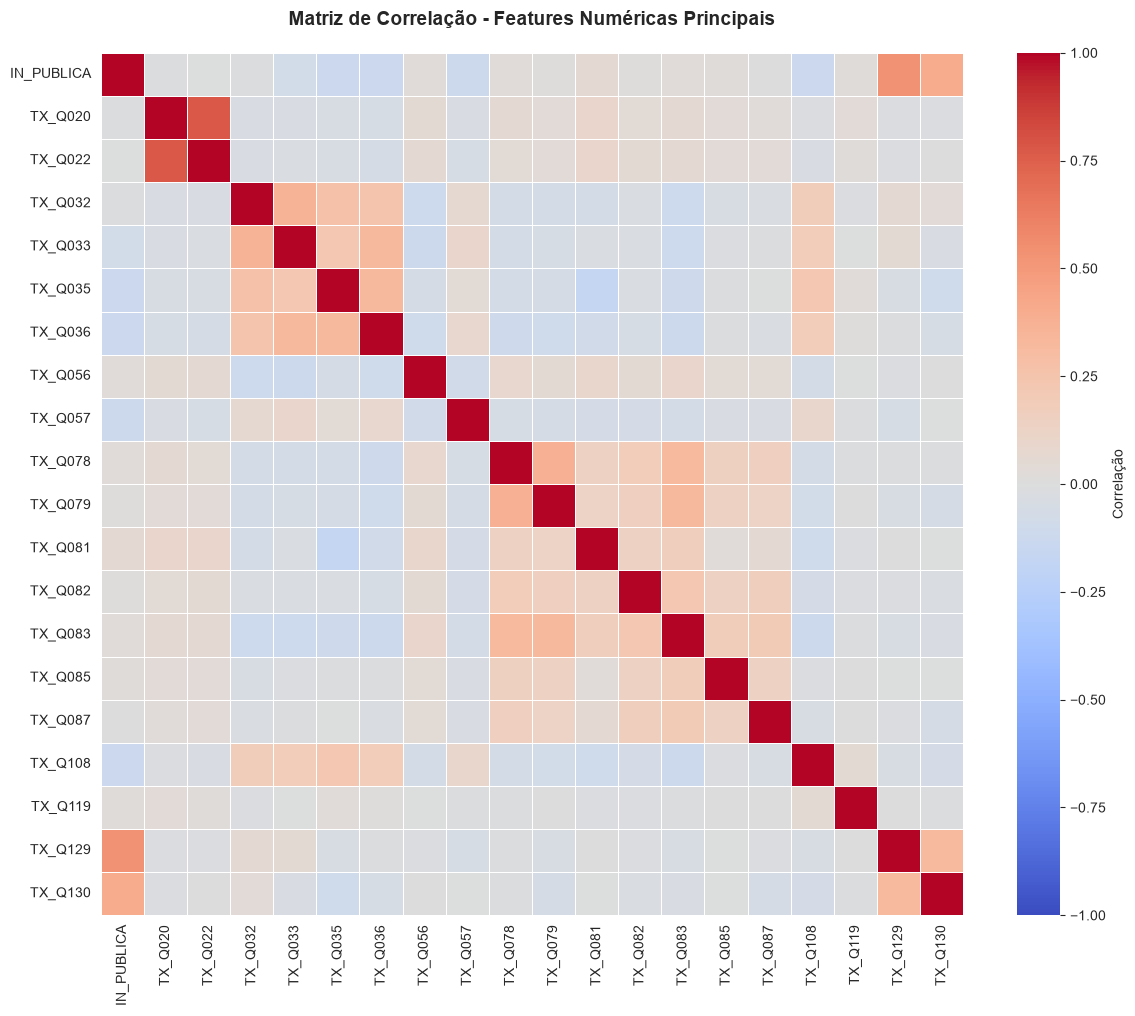

✓ Mapa de correlações criado com sucesso!


In [48]:
# Visualizar matriz de correlação (primeiras features)
if 'NIVEL_LP' in df_analise.columns or 'NIVEL_MT' in df_analise.columns:
    # Selecionar apenas as colunas numéricas relevantes (não IDs)
    cols_para_corr = [col for col in numeric_cols_all if not col.startswith('ID_')][:20]
    
    plt.figure(figsize=(12, 10))
    corr_subset = df_analise[cols_para_corr].corr()
    
    sns.heatmap(
        corr_subset,
        annot=False,
        cmap='coolwarm',
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={'label': 'Correlação'},
        vmin=-1, vmax=1
    )
    
    plt.title('Matriz de Correlação - Features Numéricas Principais', fontweight='bold', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

    print("✓ Mapa de correlações criado com sucesso!")


## 6. Resumo e Insights

### 📈 Principais Características do Dataset:


In [49]:
print("\n" + "=" * 80)
print("RESUMO EXECUTIVO DA ANÁLISE EXPLORATÓRIA")
print("=" * 80)

# Resumo geral
print("\n◉ DATASET SUMMARY:")
print(f"   • Total de amostras: {len(df_analise):,}")
print(f"   • Total de features: {len(df_analise.columns)}")
print(f"   • Features numéricas: {len(numeric_cols_all)}")
print(f"   • Features categóricas: {len(categorical_cols)}")

# Avaliar completude dos dados
missing_percentage = (df_analise.isnull().sum().sum() / (len(df_analise) * len(df_analise.columns))) * 100
print("\n◉ QUALIDADE DOS DADOS:")
print(f"   • Completude geral: {100 - missing_percentage:.2f}%")
print(f"   • Dados ausentes: {missing_percentage:.2f}%")

if missing_percentage < 5:
    print("   ✓ Qualidade Excelente! Menos de 5% de dados ausentes")
elif missing_percentage < 20:
    print("   !  Qualidade Boa. Será necessário imputação de dados")
else:
    print("   !  Atenção: Significativa quantidade de dados ausentes")

# Análise das variáveis alvo
print("\n◉ VARIÁVEIS ALVO:")
if 'NIVEL_LP' in df_analise.columns:
    unique_lp = df_analise['NIVEL_LP'].nunique()
    print(f"   • NIVEL_LP: {unique_lp} classes (Nível 0-8)")
    
    # Verificar balanceamento
    lp_counts = df_analise['NIVEL_LP'].value_counts()
    lp_ratio = lp_counts.max() / lp_counts.min()
    if lp_ratio < 3:
        print(f"      ✓ Balanceamento: Bom (proporção máx/min = {lp_ratio:.2f})")
    elif lp_ratio < 10:
        print(f"      !  Balanceamento: Moderado (proporção máx/min = {lp_ratio:.2f})")
    else:
        print(f"      !  Balanceamento: Desbalanceado (proporção máx/min = {lp_ratio:.2f})")

if 'NIVEL_MT' in df_analise.columns:
    unique_mt = df_analise['NIVEL_MT'].nunique()
    print(f"   • NIVEL_MT: {unique_mt} classes (Nível 0-10)")
    
    # Verificar balanceamento
    mt_counts = df_analise['NIVEL_MT'].value_counts()
    mt_ratio = mt_counts.max() / mt_counts.min()
    if mt_ratio < 3:
        print(f"      ✓ Balanceamento: Bom (proporção máx/min = {mt_ratio:.2f})")
    elif mt_ratio < 10:
        print(f"      !  Balanceamento: Moderado (proporção máx/min = {mt_ratio:.2f})")
    else:
        print(f"      !  Balanceamento: Desbalanceado (proporção máx/min = {mt_ratio:.2f})")

print("\n◉ RECOMENDAÇÕES PARA MODELAGEM:")
print("   • Usar validação cruzada estratificada para garantir distribuição balanceada dos folds")
print("   • Implementar pipeline de pré-processamento com imputação de dados ausentes")
print("   • Considerar técnicas de balanceamento de classes se o desbalanceamento for severo")
print("   • Normalizar/Padronizar features numéricas antes de treinar modelos sensíveis à escala")
print("   • Aplicar one-hot encoding às variáveis categóricas")
print("   • Analisar correlações durante seleção de features para evitar multicolinearidade")

print("\n" + "=" * 80)
print("✓ ANÁLISE EXPLORATÓRIA CONCLUÍDA COM SUCESSO")
print("=" * 80)



RESUMO EXECUTIVO DA ANÁLISE EXPLORATÓRIA

◉ DATASET SUMMARY:
   • Total de amostras: 1,514,448
   • Total de features: 80
   • Features numéricas: 41
   • Features categóricas: 39

◉ QUALIDADE DOS DADOS:
   • Completude geral: 92.87%
   • Dados ausentes: 7.13%
   !  Qualidade Boa. Será necessário imputação de dados

◉ VARIÁVEIS ALVO:
   • NIVEL_LP: 9 classes (Nível 0-8)
      !  Balanceamento: Desbalanceado (proporção máx/min = 244.23)
   • NIVEL_MT: 11 classes (Nível 0-10)
      !  Balanceamento: Desbalanceado (proporção máx/min = 3880.11)

◉ RECOMENDAÇÕES PARA MODELAGEM:
   • Usar validação cruzada estratificada para garantir distribuição balanceada dos folds
   • Implementar pipeline de pré-processamento com imputação de dados ausentes
   • Considerar técnicas de balanceamento de classes se o desbalanceamento for severo
   • Normalizar/Padronizar features numéricas antes de treinar modelos sensíveis à escala
   • Aplicar one-hot encoding às variáveis categóricas
   • Analisar corre